# **Sistema de Triaje Inteligente para Detección de Fraudes en Reclamaciones de Vehículos de Motor**


Sistema de Detección de Fraude Híbrido (Tabular + NLP)
------------------------------------------------------
Este script entrena y despliega un modelo de ensamblado (Stacking) que combina:
1. XGBoost: Para análisis de datos estructurados (tabulares).
2. DistilBERT + Keras NN: Para análisis de texto (descripciones de siniestros).
3. Meta-Learner (Keras): Para combinar las predicciones de ambos modelos.
Incluye una interfaz gráfica generada con ipywidgets para pruebas en tiempo real.


## El Problema: Fraude en Aumento
* Impacto Financiero: El fraude representa cerca del 10% de los costos por siniestros, generando pérdidas de cientos de miles de millones de dólares anuales.

* Consecuencia Social: Estas pérdidas no solo afectan a las aseguradoras, sino que encarecen las primas para todos los clientes.

## Limitaciones del Modelo Actual
Históricamente, las empresas han dependido de dos métodos que hoy resultan insuficientes:

* Ajustadores Humanos: Sufren de fatiga por el volumen masivo de reclamos.

* Sistemas de Reglas Estáticas: Son rígidos y fáciles de evadir para criminales que aprenden rápido a "burlar el sistema".

## La Solución: Triaje Inteligente con IA
La propuesta consiste en diseñar un Sistema de Triaje Inteligente basado en IA multimodal.

* La Hipótesis Central: El fraude se detecta mejor al encontrar inconsistencias entre los datos estructurados (hechos objetivos) y el relato del asegurado (narrativa subjetiva).

### El sistema busca capturar el contexto semántico del texto que los métodos actuales ignoran, permitiendo una detección mucho más precisa y profunda.

## Descripción del Dataset
### Dataset de Siniestros (Modelo Híbrido)

A continuación se describe la estructura del dataset generado para el entrenamiento del modelo de inteligencia artificial para la detección de fraudes en reclamaciones. El dataset combina variables estructuradas con procesamiento de lenguaje natural (PLN).

## 1. Datos del Asegurado

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Customer_Age` | Numérico (Int) | Edad del cliente al momento del reclamo. |
| `Gender` | Categórico | Género del asegurado (`M`, `F`). |
| `Insured_MaritalStatus` | Categórico | Estado civil (`Soltero`, `Casado`, `Divorciado`, `Viudo`). |
| `Insured_Occupation` | Categórico | Profesión u oficio del asegurado. |
| `Insured_Zip` | Categórico | Código postal de residencia del asegurado. |

## 2. Información de la Póliza y Cobertura

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Insured_Inception_Date` | Fecha | Fecha original en la que el cliente ingresó a la aseguradora. |
| `Policy_Start_Date` | Fecha | Inicio de la vigencia de la póliza actual. |
| `Policy_Renewal_Date` | Fecha | Fecha de la próxima renovación. |
| `Last_Purchase_History_Date` | Fecha | Última vez que el cliente modificó coberturas o adquirió un producto. |
| `Coverage_description` | Categórico | Tipo de cobertura principal contratada. |
| `Coverage_Amount` | Numérico (Float) | Límite máximo de responsabilidad de la aseguradora. |
| `Premium_Amount` | Numérico (Float) | Prima pagada por el cliente. |
| `Beneficiary_Type_Description`| Categórico | Quién recibe el pago (`Asegurado`, `Tercero`, `Banco/Financiera`). |

## 3. Historial de Reclamaciones (Comportamiento)

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Claim_History_Count_This_Policy` | Numérico (Int) | Total de reclamos históricos bajo esta póliza. |
| `Claim_Frequency_Last_12_Month` | Numérico (Int) | Número de reclamos en el último año. |

## 4. Detalles del Vehículo Asegurado

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Vehicle_Make` | Categórico | Marca del vehículo (ej. Honda, Hyundai, Kia). |
| `Vehicle_Model` | Categórico | Modelo específico (ej. Civic, Sonata). |
| `Model_Year` | Numérico (Int) | Año de fabricación del vehículo. |

## 5. Detalles del Siniestro y Reclamo

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Incident_Date` | Fecha/Hora | Cuándo ocurrió el accidente. |
| `Date_Reported` | Fecha/Hora | Cuándo el cliente notificó a la aseguradora. |
| `Claim_Amount` | Numérico (Float) | Monto monetario estimado del reclamo. |
| `LossType_Description` | Categórico | Clasificación técnica del daño (`Pérdida Parcial`, `Pérdida Total`). |
| `Branch_Description` | Categórico | Sucursal que originó o gestiona el reclamo. |
| `WorkShop_Name` | Categórico | Taller seleccionado para la reparación. |

## 6. Datos No Estructurados y Variable Objetivo (Core Híbrido)

| Columna | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| `Claim_Description` | Texto | Relato libre del asegurado sobre cómo ocurrió el siniestro. |
| `Prediccion_Fraude` | Numérico (Int) | **Variable Objetivo (Target):** `1` = Fraude, `0` = Legítimo. |

In [ ]:
import numpy as np
import tensorflow as tf
import random
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import ipywidgets as widgets
from pathlib import Path
from IPython.display import display, clear_output, HTML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score, roc_curve
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import torch
from transformers import AutoTokenizer, AutoModel
import re

PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR = PROJECT_ROOT / "ml" / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "ml" / "artifacts"
VIZ_DIR = PROJECT_ROOT / "ml" / "visualizations"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def set_random_seed(seed_value):
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    torch.manual_seed(seed_value)
    random.seed(seed_value)
    print(f"[*] Semillas aleatorias fijadas en {seed_value}.")

set_random_seed(42)
plt.style.use('ggplot')

[*] Semillas aleatorias fijadas en 42.


In [ ]:
print("\n[*] 1. Cargando datos...")
file_path = DATA_DIR / "dataset_reclamos_ia_ruidoso_extremo.xlsx"
df = pd.read_excel(file_path)


[*] 1. Cargando datos...
Mounted at /content/drive/


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_Age                     5000 non-null   int64  
 1   Claim_Amount                     5000 non-null   float64
 2   Claim_History_Count_This_Policy  5000 non-null   int64  
 3   Claim_Frequency_Last_12_Month    5000 non-null   int64  
 4   Claim_Description                5000 non-null   object 
 5   Gender                           5000 non-null   object 
 6   Last_Purchase_History_Date       5000 non-null   object 
 7   Policy_Start_Date                5000 non-null   object 
 8   Policy_Renewal_Date              5000 non-null   object 
 9   Coverage_Amount                  5000 non-null   float64
 10  Premium_Amount                   5000 non-null   float64
 11  Incident_Date                    5000 non-null   object 
 12  Date_Reported       

In [ ]:
print("[*] Feature Engineering Tabular...")

date_cols = ['Incident_Date', 'Date_Reported', 'Policy_Start_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['Report_Delay'] = (df['Date_Reported'] - df['Incident_Date']).dt.days.fillna(0)
df['Days_Since_Policy'] = (df['Incident_Date'] - df['Policy_Start_Date']).dt.days.fillna(0)
df['Car_Age'] = df['Incident_Date'].dt.year - df['Model_Year']

df = df.select_dtypes(exclude=['datetime64'])
df = df.drop(columns=['Claim_ID', 'Policy_Number', 'Last_Purchase_History_Date',
                      'Policy_Renewal_Date', 'Insured_Inception_Date', 'Model_Year'], errors='ignore')

label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Claim_Description':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

X_tab_df = df.drop(columns=['Claim_Description', 'Prediccion_Fraude'])
X_tab_features = X_tab_df.columns.tolist()
X_tab = X_tab_df.values
y = df['Prediccion_Fraude'].values
text_data = df['Claim_Description'].astype(str).tolist()

[*] Feature Engineering Tabular...


In [6]:
X_tab_features

['Customer_Age',
 'Claim_Amount',
 'Claim_History_Count_This_Policy',
 'Claim_Frequency_Last_12_Month',
 'Gender',
 'Coverage_Amount',
 'Premium_Amount',
 'Insured_MaritalStatus',
 'Insured_Occupation',
 'Coverage_description',
 'LossType_Description',
 'Branch_Description',
 'Beneficiary_Type_Description',
 'WorkShop_Name',
 'Insured_Zip',
 'Vehicle_Make',
 'Vehicle_Model',
 'Report_Delay',
 'Days_Since_Policy',
 'Car_Age']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_Age                     5000 non-null   int64  
 1   Claim_Amount                     5000 non-null   float64
 2   Claim_History_Count_This_Policy  5000 non-null   int64  
 3   Claim_Frequency_Last_12_Month    5000 non-null   int64  
 4   Claim_Description                5000 non-null   object 
 5   Gender                           5000 non-null   int64  
 6   Coverage_Amount                  5000 non-null   float64
 7   Premium_Amount                   5000 non-null   float64
 8   Insured_MaritalStatus            5000 non-null   int64  
 9   Insured_Occupation               5000 non-null   int64  
 10  Coverage_description             5000 non-null   int64  
 11  LossType_Description             5000 non-null   int64  
 12  Branch_Description  

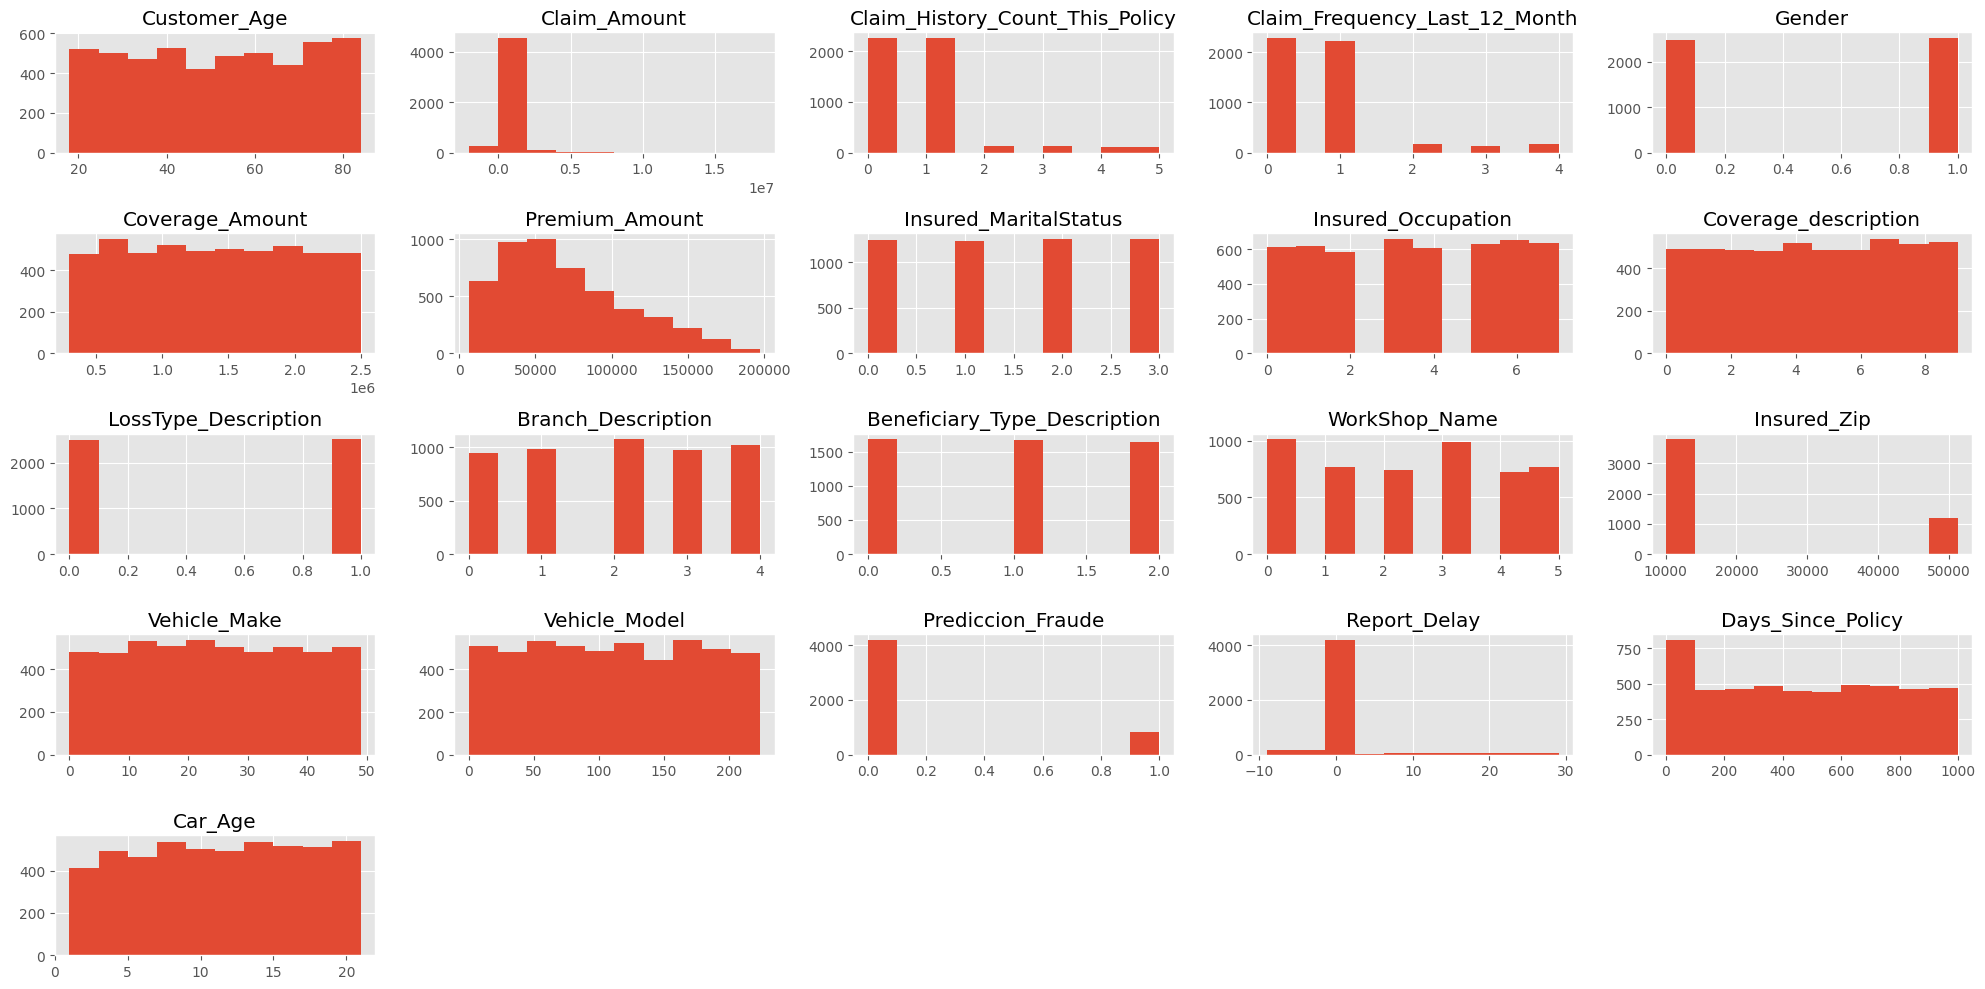

In [ ]:
plt.rcParams['figure.figsize'] = [20, 10]
df.hist()
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.tight_layout()
plt.savefig(VIZ_DIR / "histogramas_variables.png", dpi=150, bbox_inches='tight')
plt.show()


In [9]:
print(f'la cantidad de registros: {df.shape[0]:,}')
print(f'la cantidad de columnas:  {df.shape[1]}')

la cantidad de registros: 5,000
la cantidad de columnas:  22


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_Age                     5000 non-null   int64  
 1   Claim_Amount                     5000 non-null   float64
 2   Claim_History_Count_This_Policy  5000 non-null   int64  
 3   Claim_Frequency_Last_12_Month    5000 non-null   int64  
 4   Claim_Description                5000 non-null   object 
 5   Gender                           5000 non-null   int64  
 6   Coverage_Amount                  5000 non-null   float64
 7   Premium_Amount                   5000 non-null   float64
 8   Insured_MaritalStatus            5000 non-null   int64  
 9   Insured_Occupation               5000 non-null   int64  
 10  Coverage_description             5000 non-null   int64  
 11  LossType_Description             5000 non-null   int64  
 12  Branch_Description  

In [11]:
df.describe()

,Customer_Age,Claim_Amount,Claim_History_Count_This_Policy,Claim_Frequency_Last_12_Month,Gender,Coverage_Amount,Premium_Amount,Insured_MaritalStatus,Insured_Occupation,Coverage_description,...,Branch_Description,Beneficiary_Type_Description,WorkShop_Name,Insured_Zip,Vehicle_Make,Vehicle_Model,Prediccion_Fraude,Report_Delay,Days_Since_Policy,Car_Age
count,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,51.445800,5.123133e+05,0.790000,0.744800,0.503800,1.393368e+06,69661.274700,1.505000,3.538400,4.569800,...,2.028200,0.993200,2.387400,20494.476000,24.520400,111.153000,0.163000,2.003600,468.814200,10.817800
std,19.617993,1.105958e+06,1.056467,0.932227,0.500036,6.326668e+05,41173.578766,1.119744,2.292155,2.882775,...,1.402212,0.816387,1.723228,17232.288568,14.289017,64.312353,0.369403,5.511593,306.620784,5.706445
min,18.000000,-2.062464e+06,0.000000,0.000000,0.000000,3.002414e+05,6097.460000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,10101.000000,0.000000,0.000000,0.000000,-9.000000,1.000000,1.000000
25%,34.000000,1.246255e+05,0.000000,0.000000,0.000000,8.461657e+05,37495.602500,1.000000,2.000000,2.000000,...,1.000000,0.000000,1.000000,10509.000000,12.000000,57.000000,0.000000,0.000000,199.000000,6.000000
50%,51.000000,2.679759e+05,1.000000,1.000000,1.000000,1.390053e+06,61105.690000,2.000000,4.000000,5.000000,...,2.000000,1.000000,2.000000,10580.000000,24.000000,110.000000,0.000000,1.000000,465.000000,11.000000
75%,69.000000,5.328603e+05,1.000000,1.000000,1.000000,1.933804e+06,95155.692500,3.000000,6.000000,7.000000,...,3.000000,2.000000,4.000000,11503.000000,37.000000,166.000000,0.000000,2.000000,737.000000,16.000000
max,84.000000,1.813367e+07,5.000000,4.000000,1.000000,2.499897e+06,197530.810000,3.000000,7.000000,9.000000,...,4.000000,2.000000,5.000000,51200.000000,49.000000,224.000000,1.000000,29.000000,999.000000,21.000000


In [12]:
df.head(20)

,Customer_Age,Claim_Amount,Claim_History_Count_This_Policy,Claim_Frequency_Last_12_Month,Claim_Description,Gender,Coverage_Amount,Premium_Amount,Insured_MaritalStatus,Insured_Occupation,...,Branch_Description,Beneficiary_Type_Description,WorkShop_Name,Insured_Zip,Vehicle_Make,Vehicle_Model,Prediccion_Fraude,Report_Delay,Days_Since_Policy,Car_Age
0,74,116281.22,0,1,"El 15 de octubre, mientras manejaba por la Av....",1,1756012.19,50844.40,3,5,...,3,1,0,51100,40,163,0,1,112,4
1,44,68880.28,0,0,"El 24 de octubre, tuve un accidente mientras c...",0,475779.24,26602.04,1,0,...,2,0,0,10508,25,196,0,1,654,2
2,23,351069.98,1,1,"El pasado 15 de octubre, tuve un accidente con...",0,995928.65,63822.09,0,5,...,1,0,0,11503,30,161,0,0,469,1
3,48,678643.73,1,0,"El 15 de octubre, mientras manejaba mi vehícul...",0,2106085.57,85587.93,2,5,...,1,2,4,11501,33,44,0,1,601,4
4,55,94343.33,0,0,El pasado 12 de octubre tuve un accidente con ...,1,345467.81,25060.79,1,6,...,4,1,0,11503,47,164,0,2,192,3
5,68,604224.73,0,1,"El 22 de octubre, mientras conducía por la Ave...",0,1819547.56,52479.73,2,1,...,3,1,4,10509,28,60,0,2,524,15
6,34,129915.05,1,0,"El pasado martes, tuve un accidente con mi veh...",1,643758.13,47354.17,0,1,...,1,1,5,11503,4,180,0,2,834,18
7,59,479399.82,4,2,El vehículo se vio involucrado en un incidente...,0,520662.96,22340.30,0,1,...,2,1,0,10509,32,25,1,20,5,10
8,20,55804.57,1,0,"El 15 de octubre, mientras conducía por la aut...",1,578501.02,45747.23,0,7,...,0,1,4,10520,34,142,0,2,278,7
9,76,203073.90,1,0,"El 10 de octubre, tuve un accidente donde mi v...",1,588698.70,45949.72,3,7,...,4,1,5,10101,27,54,0,1,791,10


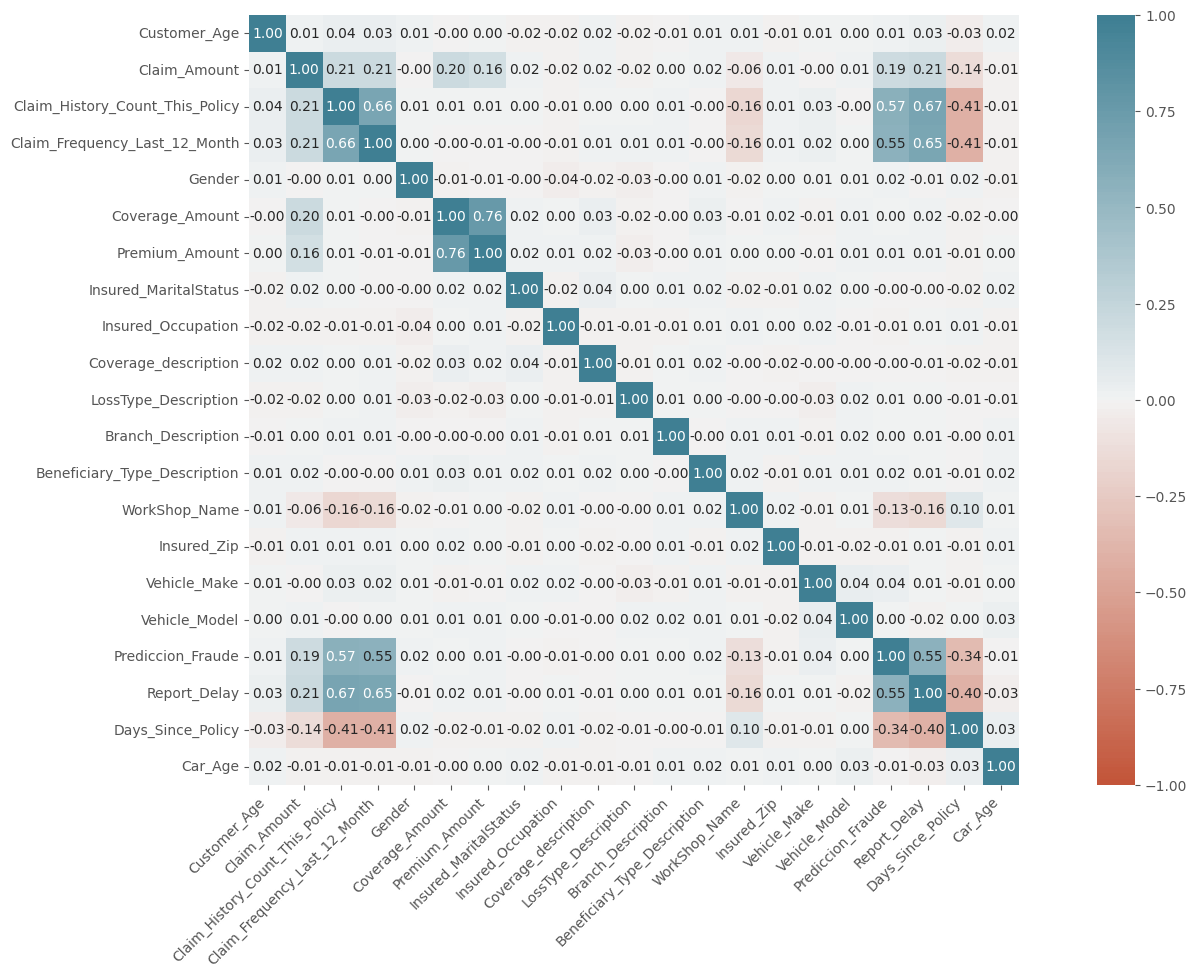

In [ ]:
corr = df.corr(numeric_only=True)
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot=True,
    fmt=".2f"
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.tight_layout()
plt.savefig(VIZ_DIR / "correlacion_variables.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
col_total_nulos = df.isnull().sum()
serie_col_nombres = col_total_nulos[col_total_nulos > 0]
display(serie_col_nombres)

df.isna().sum()

,0


,0
Customer_Age,0
Claim_Amount,0
Claim_History_Count_This_Policy,0
Claim_Frequency_Last_12_Month,0
Claim_Description,0
Gender,0
Coverage_Amount,0
Premium_Amount,0
Insured_MaritalStatus,0
Insured_Occupation,0


In [ ]:
(df==0).sum(axis=0)

,0
Customer_Age,0
Claim_Amount,0
Claim_History_Count_This_Policy,2255
Claim_Frequency_Last_12_Month,2280
Claim_Description,0
Gender,2481
Coverage_Amount,0
Premium_Amount,0
Insured_MaritalStatus,1249
Insured_Occupation,614


All numerical columns: ['Customer_Age', 'Claim_Amount', 'Claim_History_Count_This_Policy', 'Claim_Frequency_Last_12_Month', 'Gender', 'Coverage_Amount', 'Premium_Amount', 'Insured_MaritalStatus', 'Insured_Occupation', 'Coverage_description', 'LossType_Description', 'Branch_Description', 'Beneficiary_Type_Description', 'WorkShop_Name', 'Insured_Zip', 'Vehicle_Make', 'Vehicle_Model', 'Prediccion_Fraude', 'Report_Delay', 'Days_Since_Policy', 'Car_Age']
big_values_columns column: ['Claim_Amount', 'Coverage_Amount', 'Premium_Amount', 'Insured_Zip', 'Customer_Age']
Other numerical columns (excluding Claim_Amount): ['Claim_History_Count_This_Policy', 'Claim_Frequency_Last_12_Month', 'Gender', 'Insured_MaritalStatus', 'Insured_Occupation', 'Coverage_description', 'LossType_Description', 'Branch_Description', 'Beneficiary_Type_Description', 'WorkShop_Name', 'Vehicle_Make', 'Vehicle_Model', 'Prediccion_Fraude', 'Report_Delay', 'Days_Since_Policy', 'Car_Age']


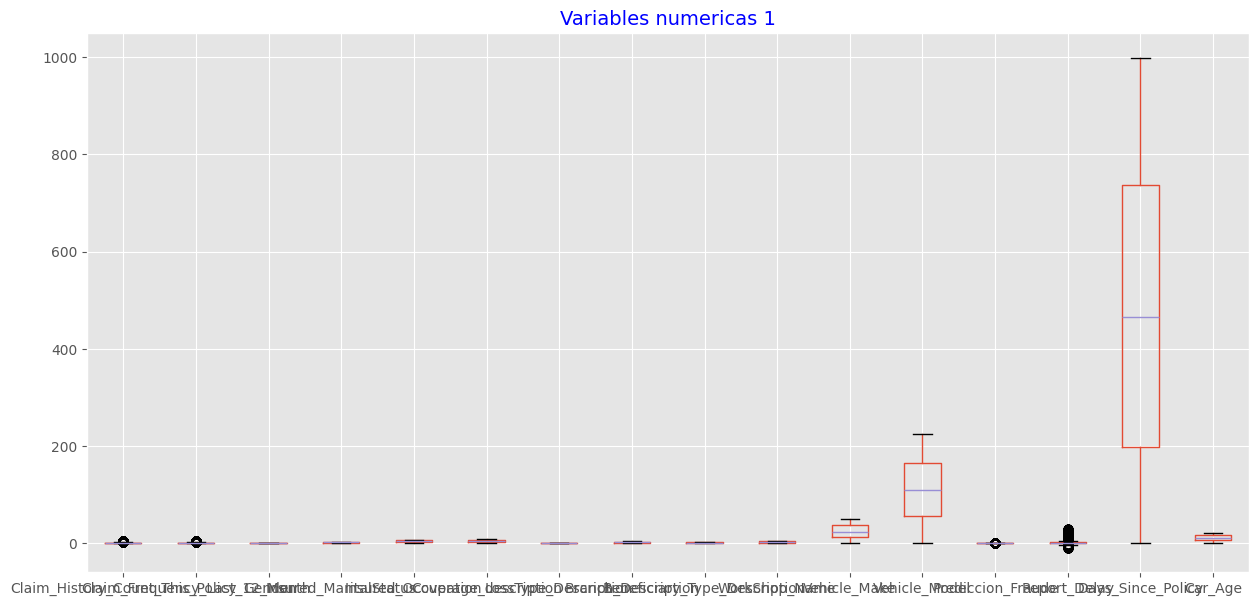

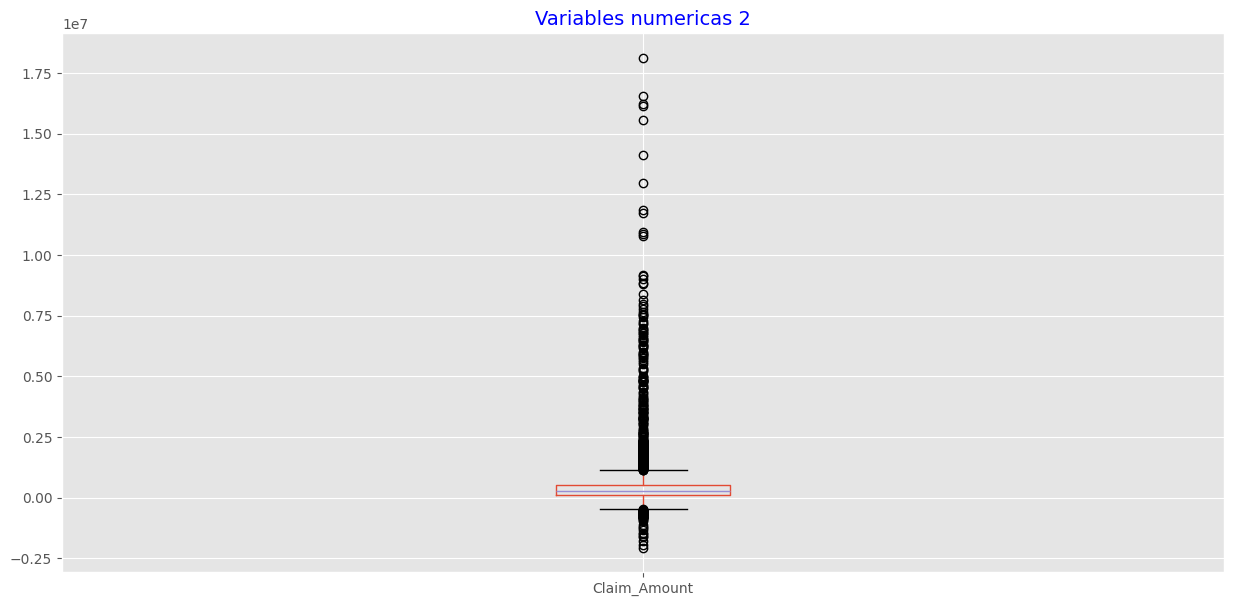

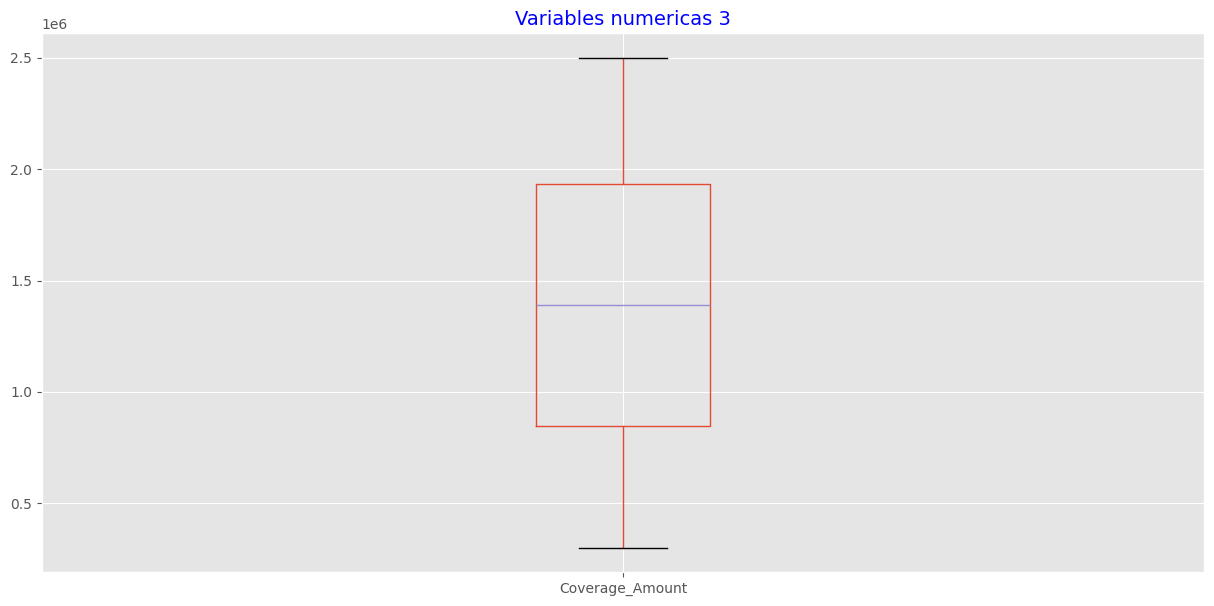

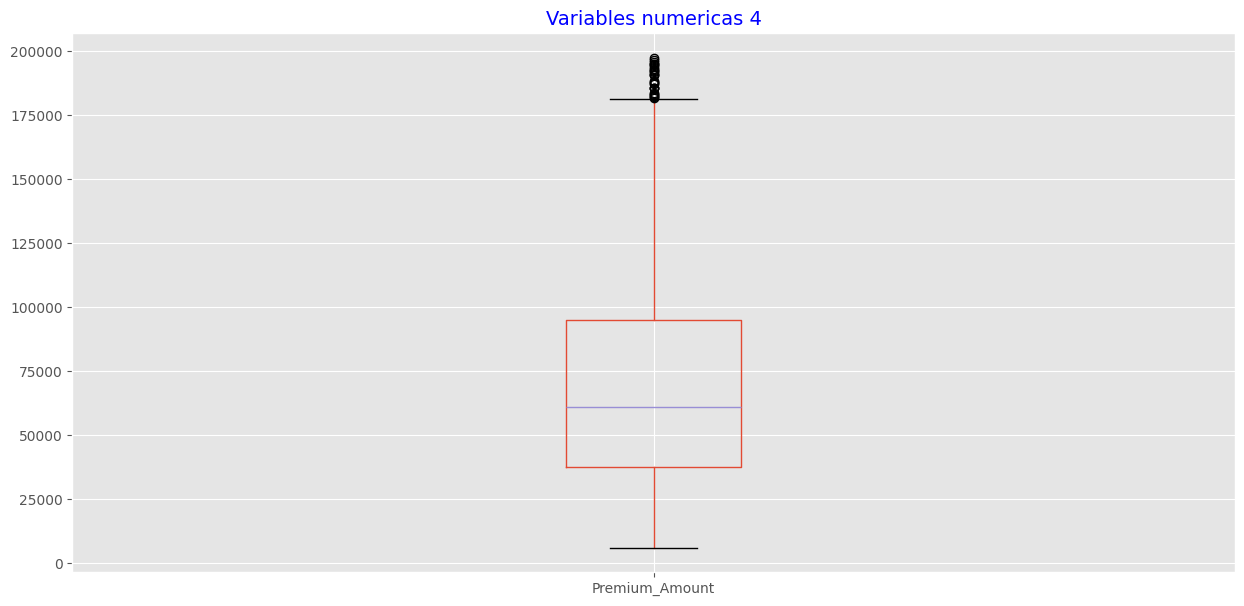

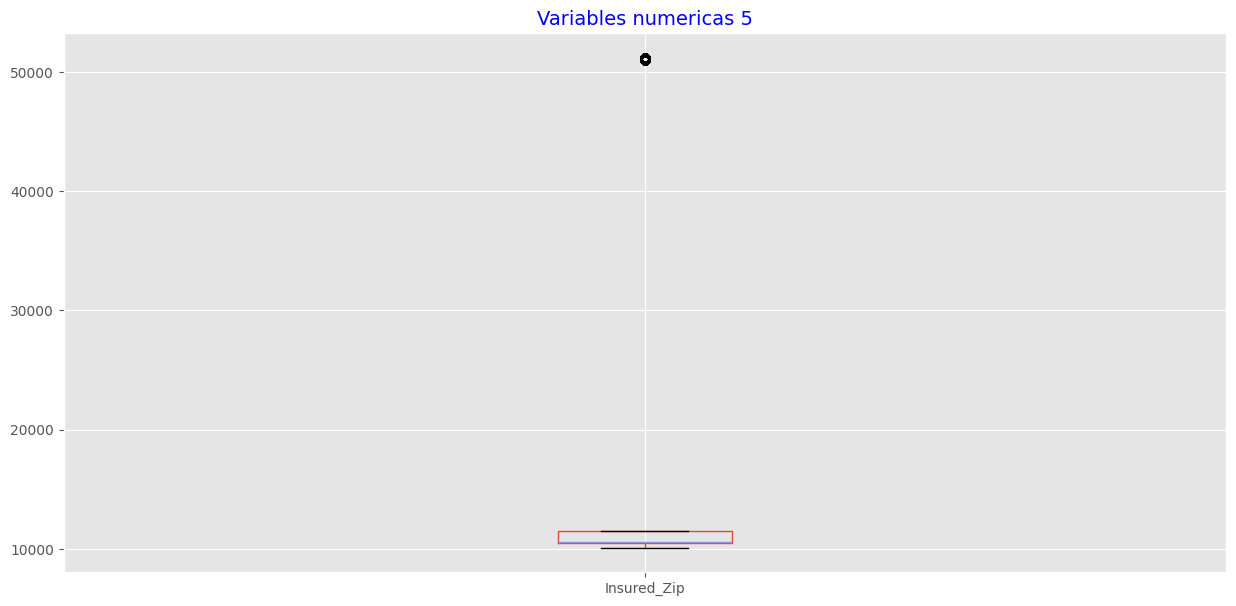

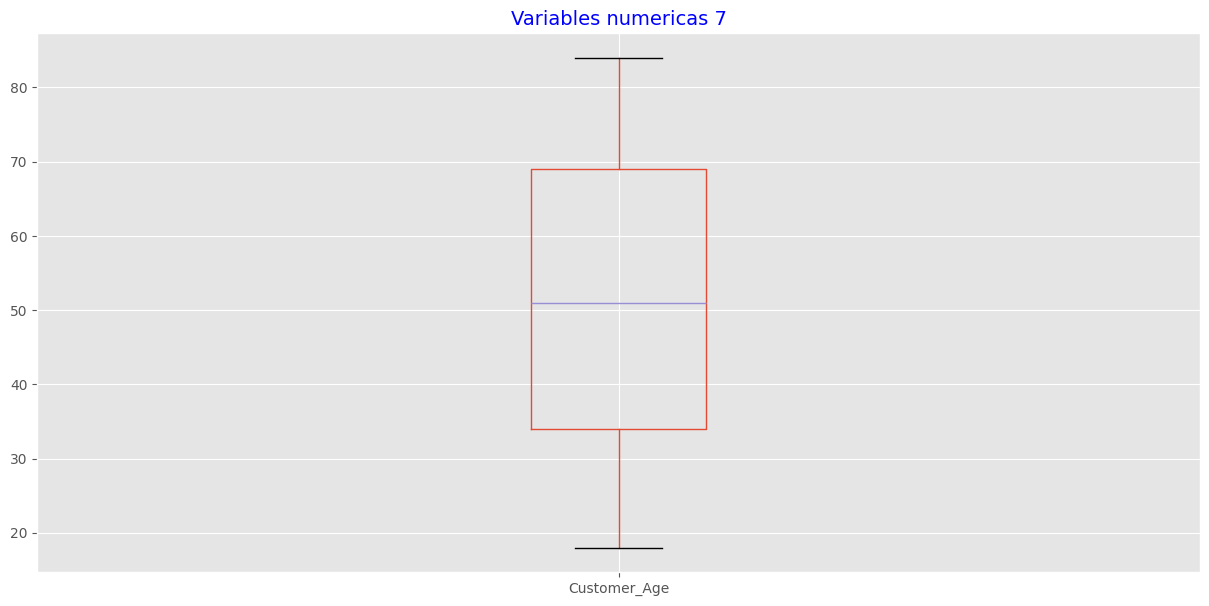

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
big_values_columns = ['Claim_Amount', 'Coverage_Amount', 'Premium_Amount', 'Insured_Zip', 'Customer_Age']
small_numerical_cols = [col for col in numerical_cols if col not in big_values_columns]

print(f"All numerical columns: {numerical_cols}")
print(f"big_values_columns column: {big_values_columns}")
print(f"Other numerical columns: {small_numerical_cols}")

boxplot = df[small_numerical_cols].boxplot(figsize=(15,7))
plt.title("Variables numericas 1", fontsize=14, color='blue')
plt.savefig(VIZ_DIR / "boxplot_variables_numericas_1.png", dpi=150, bbox_inches='tight')
plt.show()

boxplot = df[['Claim_Amount']].boxplot(figsize=(15,7))
plt.title("Variables numericas 2", fontsize=14, color='blue')
plt.savefig(VIZ_DIR / "boxplot_variables_numericas_2.png", dpi=150, bbox_inches='tight')
plt.show()

boxplot = df[['Coverage_Amount']].boxplot(figsize=(15,7))
plt.title("Variables numericas 3", fontsize=14, color='blue')
plt.savefig(VIZ_DIR / "boxplot_variables_numericas_3.png", dpi=150, bbox_inches='tight')
plt.show()

boxplot = df[['Premium_Amount']].boxplot(figsize=(15,7))
plt.title("Variables numericas 4", fontsize=14, color='blue')
plt.savefig(VIZ_DIR / "boxplot_variables_numericas_4.png", dpi=150, bbox_inches='tight')
plt.show()

boxplot = df[['Insured_Zip']].boxplot(figsize=(15,7))
plt.title("Variables numericas 5", fontsize=14, color='blue')
plt.savefig(VIZ_DIR / "boxplot_variables_numericas_5.png", dpi=150, bbox_inches='tight')
plt.show()

boxplot = df[['Customer_Age']].boxplot(figsize=(15,7))
plt.title("Variables numericas 6", fontsize=14, color='blue')
plt.savefig(VIZ_DIR / "boxplot_variables_numericas_6.png", dpi=150, bbox_inches='tight')
plt.show()


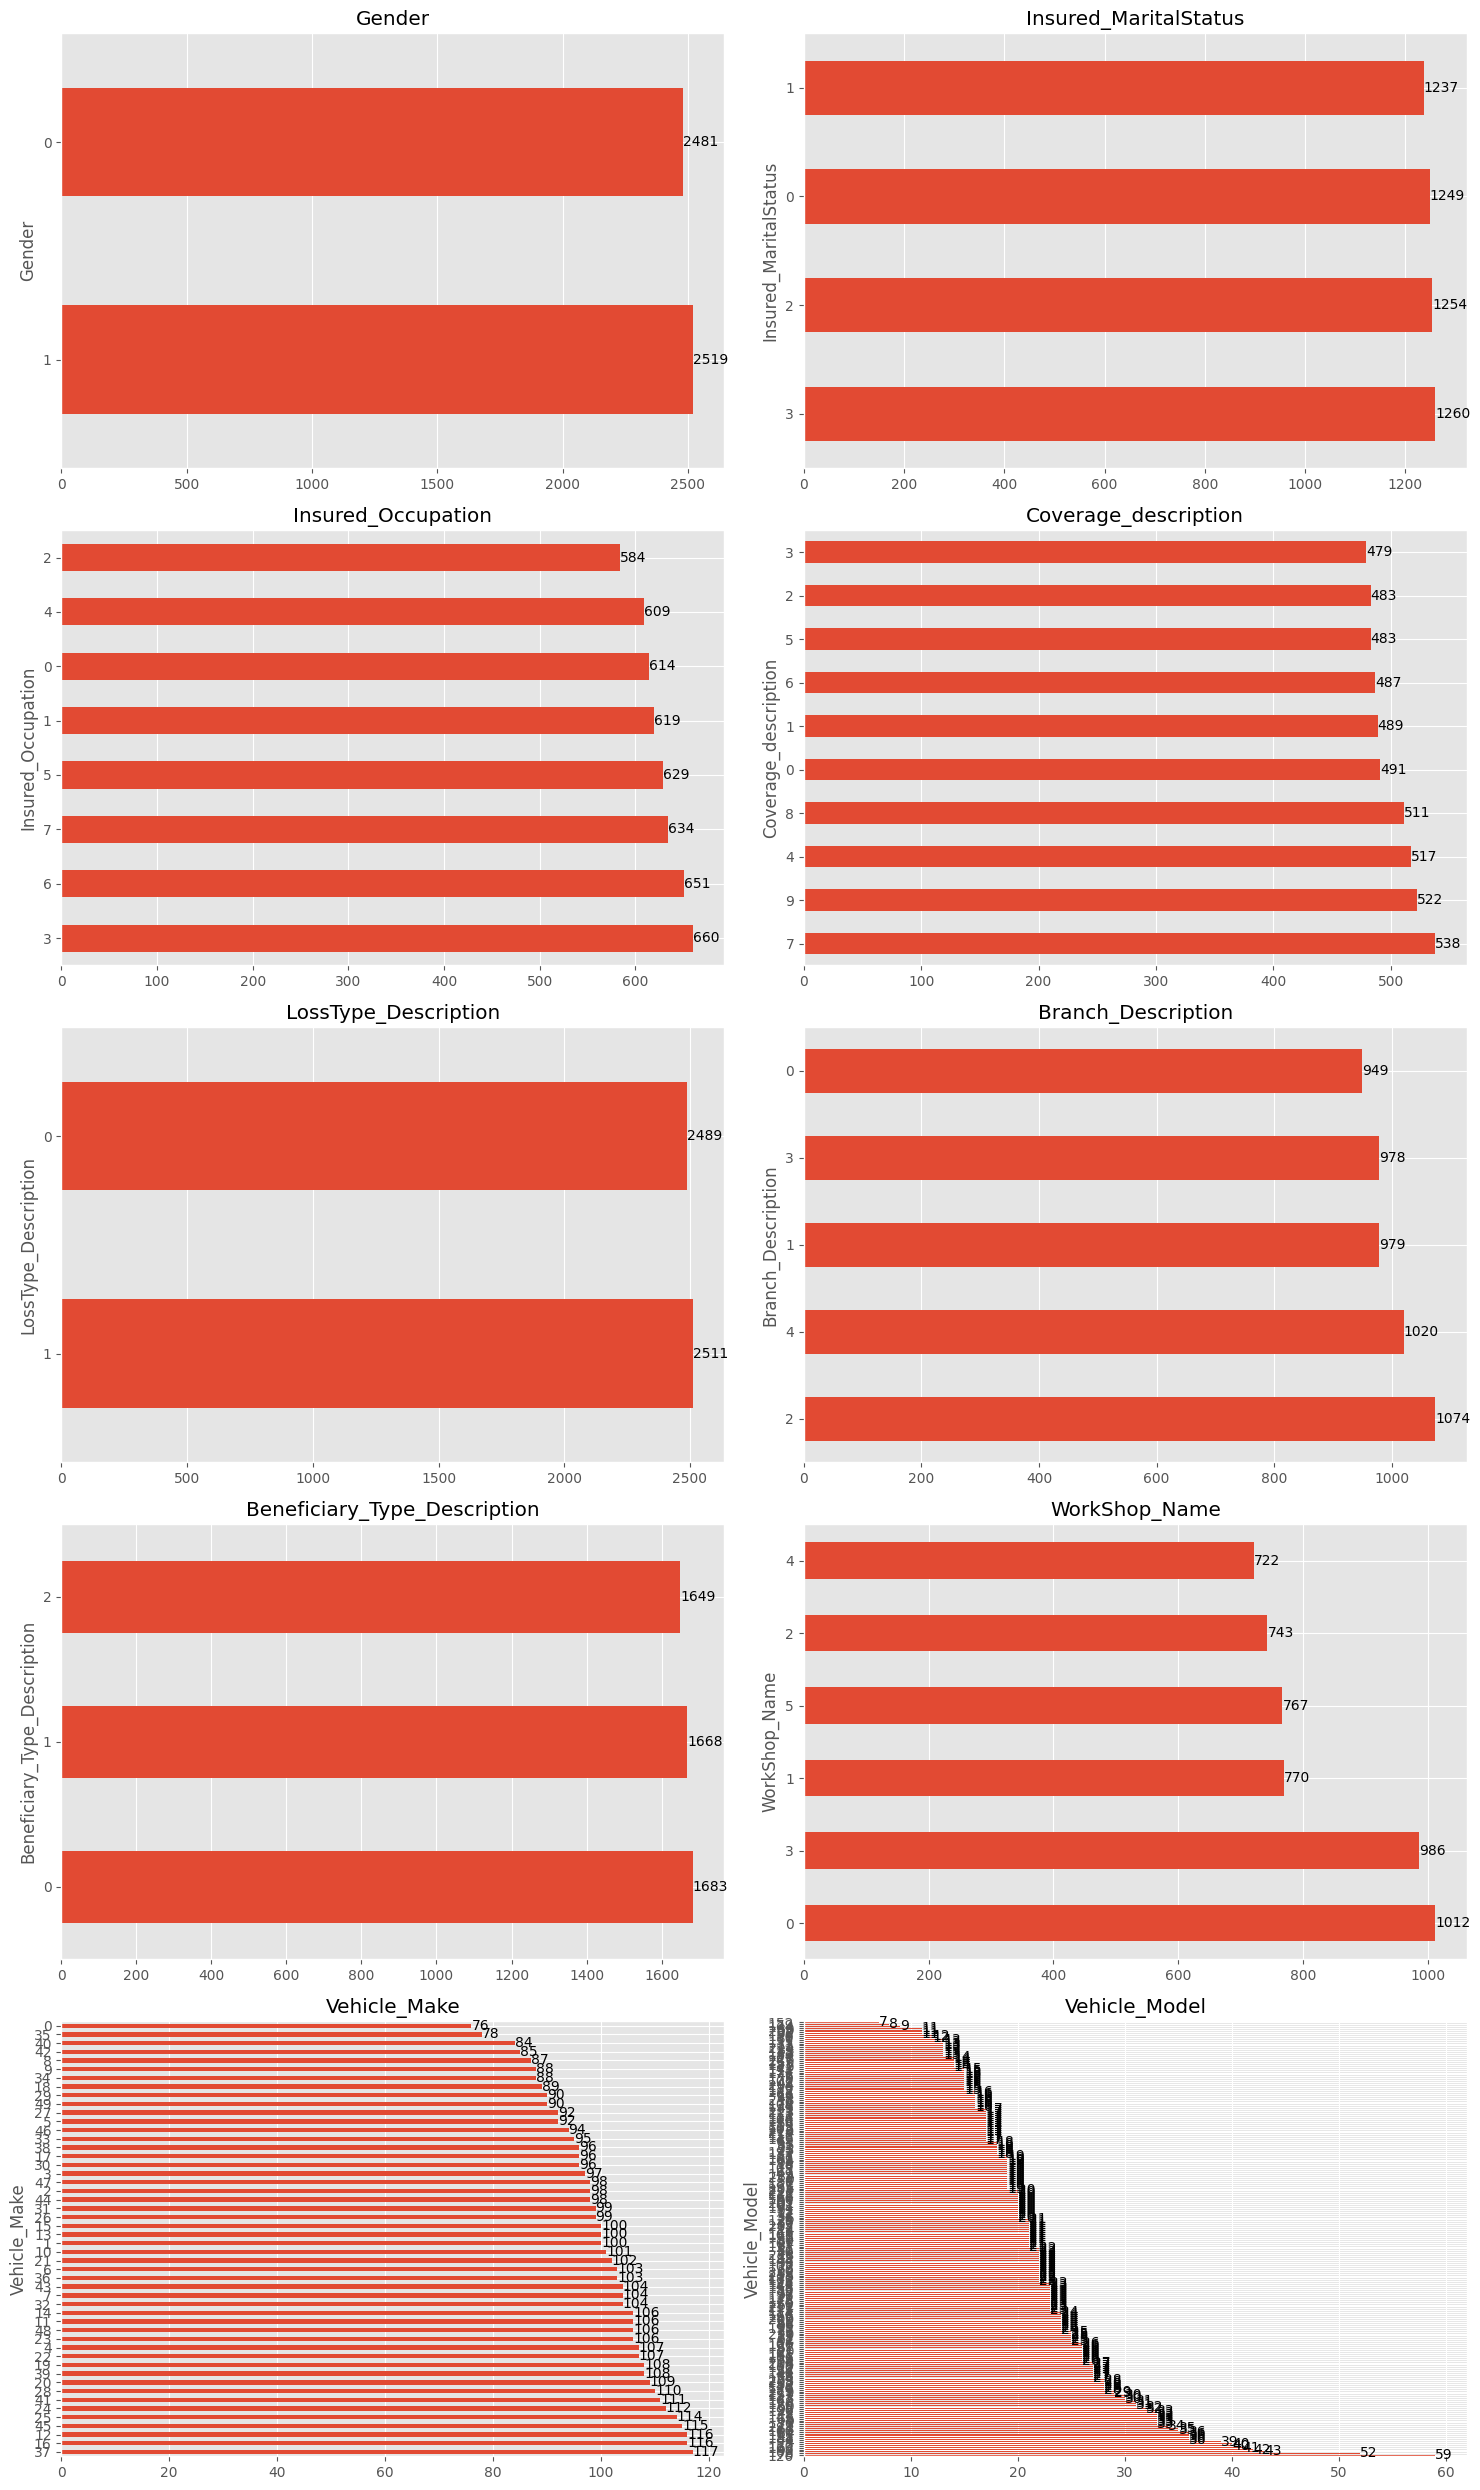

In [ ]:
lst_var_cat = list(label_encoders.keys())
num_categorical_cols = len(lst_var_cat)
nrows = (num_categorical_cols + 1) // 2
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(15, 5 * nrows))

plt.subplots_adjust(wspace=0.5, hspace=0.5)

axes = axes.flatten() if num_categorical_cols > 1 else [axes]

for i, col in enumerate(lst_var_cat):
    if i < len(axes):
        df[col].value_counts().plot.barh(ax=axes[i])
        axes[i].set_title(col)
        axes[i].bar_label(axes[i].containers[0])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(VIZ_DIR / "distribucion_variables_categoricas.png", dpi=150, bbox_inches='tight')
plt.show()


Número de registros por clase


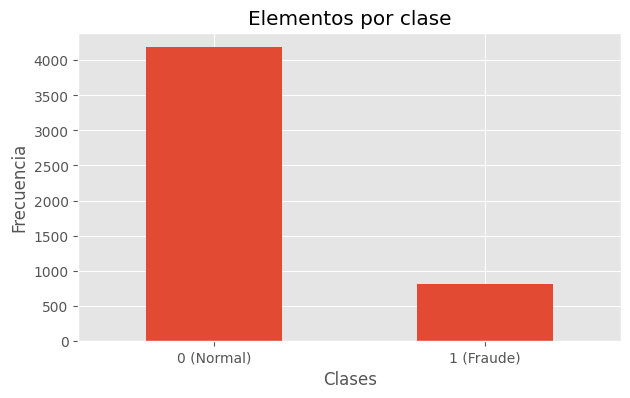

In [ ]:
class_labels = ['0 (Normal)', '1 (Fraude)']

print("Número de registros por clase")
class_counts = df['Prediccion_Fraude'].value_counts().sort_index()
ax = class_counts.plot(kind='bar', figsize=(7,4), title="Elementos por clase")
ax.set_xlabel("Clases")
ax.set_ylabel("Frecuencia")
ax.set_xticklabels(class_labels)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(VIZ_DIR / "distribucion_clases.png", dpi=150, bbox_inches='tight')
plt.show()


Analizando patrones psicológicos en los textos...

¡Gráficas guardadas como 'dashboard_marcadores_fraude_completo.png' listas para la presentación!


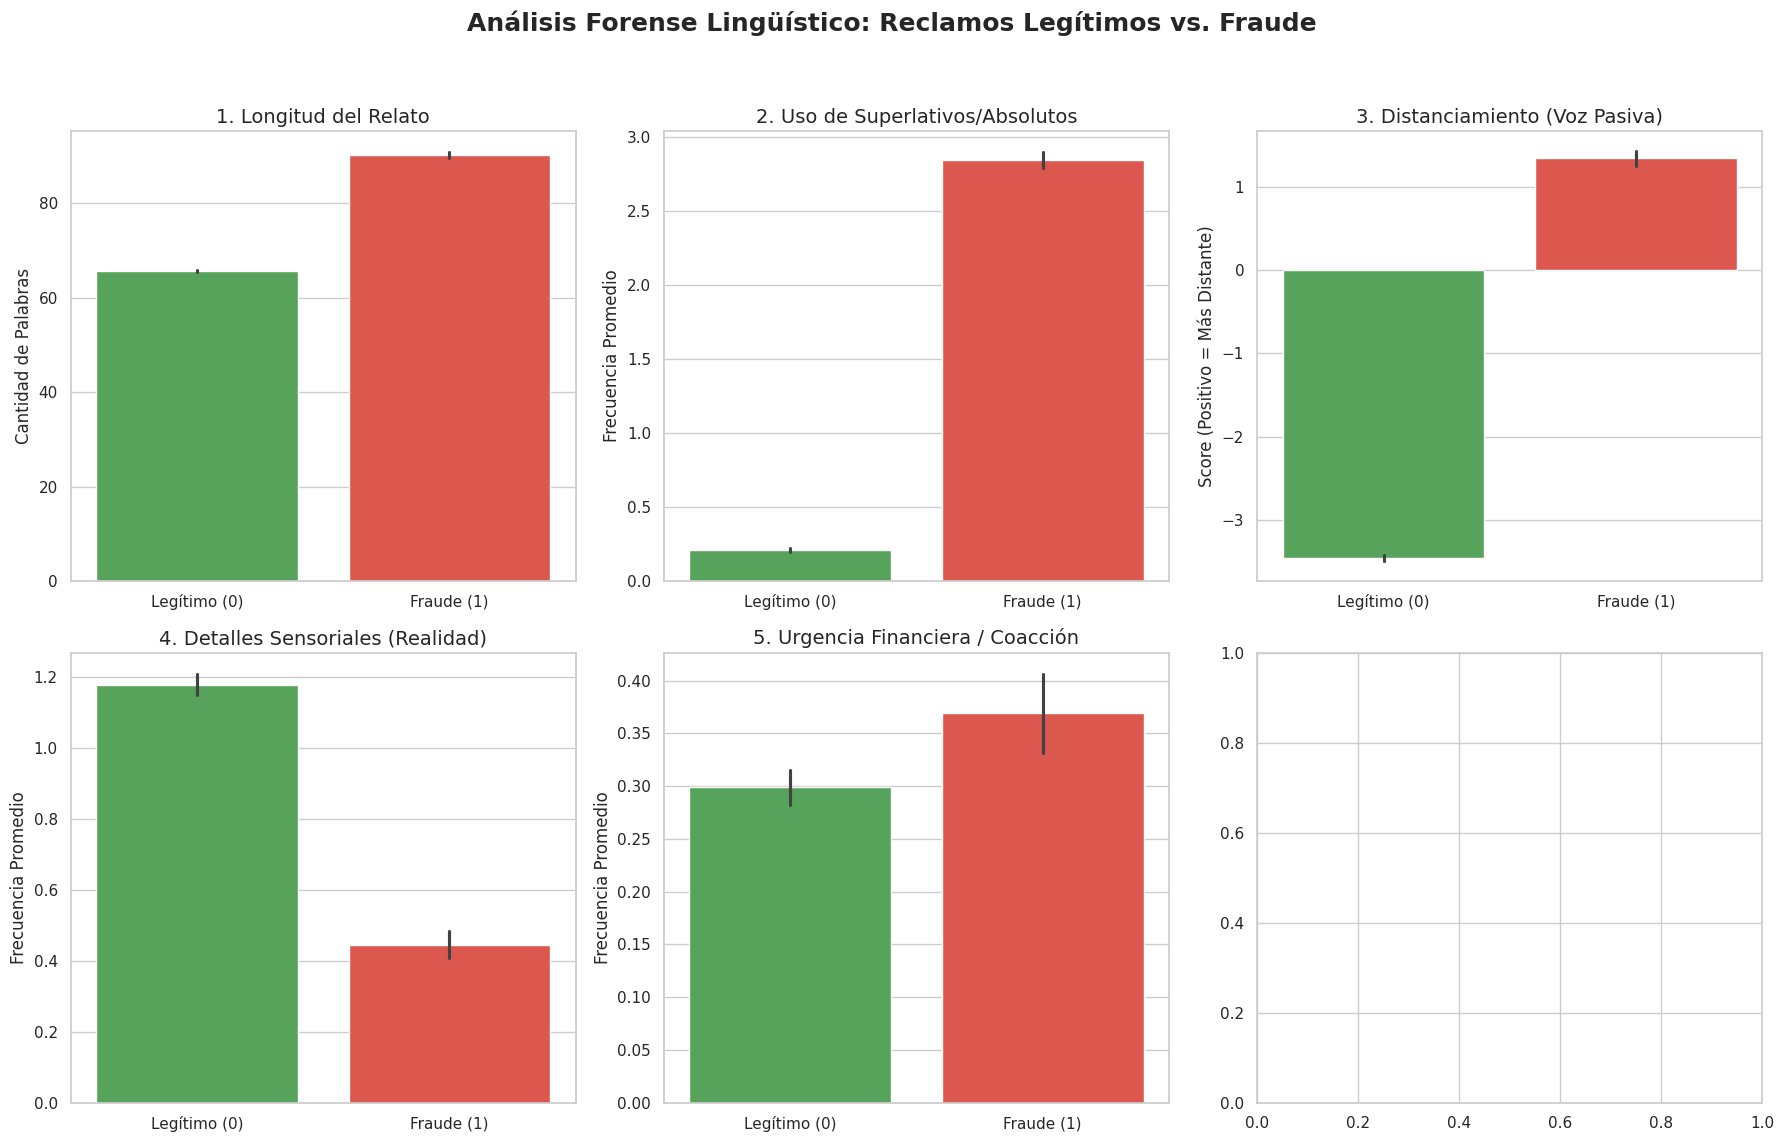

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

df['Claim_Description'] = df['Claim_Description'].fillna("")
df_nlp = df.copy()

def contar_palabras(texto):
    return len(str(texto).split())

def contar_superlativos(texto):
    patron = r'\b(absolutamente|completamente|totalmente|perfectamente|exactamente|excesivamente|definitivamente|imposible)\b'
    return len(re.findall(patron, str(texto).lower()))

def indice_distanciamiento(texto):
    texto = str(texto).lower()
    personales = len(re.findall(r'\b(yo|me|mi|mis)\b', texto))
    impersonales = len(re.findall(r'\b(el vehículo|la unidad|el auto|se produjo|fue impactado|resultó)\b', texto))
    return impersonales - personales

def indice_evasivas(texto):
    patron = r'\b(creo|parece|quizás|tal vez|aparentemente|me pareció|supongo|alrededor de|mas o menos)\b'
    return len(re.findall(patron, str(texto).lower()))

def indice_sensorial(texto):
    patron = r'\b(escuché|sonó|vi|fuerte|estruendo|ruido|olor|frenazo|golpe|impacto|tembló)\b'
    return len(re.findall(patron, str(texto).lower()))

def indice_urgencia(texto):
    patron = r'\b(rápido|urgente|necesito|dinero|paguen|abogado|inaceptable|exijo|demanda|injusto)\b'
    return len(re.findall(patron, str(texto).lower()))

print("Analizando patrones psicológicos en los textos...")
df_nlp['Word_Count'] = df_nlp['Claim_Description'].apply(contar_palabras)
df_nlp['Superlativos_Count'] = df_nlp['Claim_Description'].apply(contar_superlativos)
df_nlp['Score_Distanciamiento'] = df_nlp['Claim_Description'].apply(indice_distanciamiento)
df_nlp['Score_Sensorial'] = df_nlp['Claim_Description'].apply(indice_sensorial)
df_nlp['Score_Urgencia'] = df_nlp['Claim_Description'].apply(indice_urgencia)

estadisticas = df_nlp.groupby('Prediccion_Fraude')[
    ['Word_Count', 'Superlativos_Count', 'Score_Distanciamiento', 'Score_Sensorial', 'Score_Urgencia']
].mean().round(2)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Análisis Forense Lingüístico: Reclamos Legítimos vs. Fraude', fontsize=18, fontweight='bold')

metricas = [
    ('Word_Count', '1. Longitud del Relato', 'Cantidad de Palabras'),
    ('Superlativos_Count', '2. Uso de Superlativos/Absolutos', 'Frecuencia Promedio'),
    ('Score_Distanciamiento', '3. Distanciamiento (Voz Pasiva)', 'Score (Positivo = Más Distante)'),
    ('Score_Sensorial', '4. Detalles Sensoriales (Realidad)', 'Frecuencia Promedio'),
    ('Score_Urgencia', '5. Urgencia Financiera / Coacción', 'Frecuencia Promedio')
]

axes = axes.flatten()

for i, (columna, titulo, ylabel) in enumerate(metricas):
    sns.barplot(x='Prediccion_Fraude', y=columna, data=df_nlp, ax=axes[i], palette=['#4CAF50', '#F44336'], hue='Prediccion_Fraude', legend=False)
    axes[i].set_title(titulo, fontsize=14)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Legítimo (0)', 'Fraude (1)'])
    axes[i].set_ylabel(ylabel)
    axes[i].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(VIZ_DIR / "dashboard_marcadores_fraude_completo.png", dpi=300)
print(f"\nGráficas guardadas en {VIZ_DIR / 'dashboard_marcadores_fraude_completo.png'}")
plt.show()

In [ ]:
print("\n[*] 2. Descargando modelo DistilBERT Nativo (PyTorch)...")

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
distilbert_model = AutoModel.from_pretrained("distilbert-base-multilingual-cased")
distilbert_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
distilbert_model.to(device)
print(f"[*] Usando dispositivo: {device}")

def extract_embeddings(text_list, batch_size=32):
    all_embeddings = []
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=120, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = distilbert_model(**inputs)

        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

print("[*] Convirtiendo todos los textos a Embeddings de DistilBERT...")
X_text_embeddings = extract_embeddings(text_data)
print(f"[*] Embeddings generados con forma: {X_text_embeddings.shape}")


[*] 2. Descargando modelo DistilBERT Nativo (PyTorch)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Usando dispositivo: cuda
[*] Convirtiendo todos los textos a Embeddings de DistilBERT (Esto tomará unos segundos)...
[*] Embeddings generados con forma: (5000, 768) (Textos, Dimensiones)


In [ ]:
print("\n[*] 3. Dividiendo datos de forma estratificada...")

indices = np.arange(len(y))
idx_temp, idx_test, y_temp, y_test = train_test_split(indices, y, test_size=0.20, random_state=42, stratify=y)
idx_base, idx_meta, y_base, y_meta = train_test_split(idx_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
idx_train, idx_val, y_train, y_val = train_test_split(idx_base, y_base, test_size=0.20, random_state=42, stratify=y_base)

X_tab_train, X_tab_val, X_tab_meta, X_tab_test = X_tab[idx_train], X_tab[idx_val], X_tab[idx_meta], X_tab[idx_test]

X_text_train = X_text_embeddings[idx_train]
X_text_val   = X_text_embeddings[idx_val]
X_text_meta  = X_text_embeddings[idx_meta]
X_text_test  = X_text_embeddings[idx_test]


[*] 3. Dividiendo datos de forma estratificada...


In [22]:
print(f"Cantidad de elementos para entrenamiento: {len(idx_train)}")
print(f"Cantidad de elementos para validacion: {len(idx_val)}")
print(f"Cantidad de elementos para meta: {len(idx_meta)}")
print(f"Cantidad de elementos para test: {len(idx_test)}")

Cantidad de elementos para entrenamiento: 2400
Cantidad de elementos para validacion: 600
Cantidad de elementos para meta: 1000
Cantidad de elementos para test: 1000


In [ ]:
def evaluate_and_plot_metrics(y_true, y_pred_prob, model_name, threshold=0.5, history=None):
    safe_name = model_name.replace(' ', '_').replace('/', '-').replace('(', '').replace(')', '')

    if history:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        ax1.plot(history.history['accuracy'])
        ax1.plot(history.history['val_accuracy'])
        ax1.set_title(f'Accuracy del Modelo {model_name}')
        ax1.set_ylabel('Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.legend(['Train', 'Validation'], loc='upper left')

        ax2.plot(history.history['loss'])
        ax2.plot(history.history['val_loss'])
        ax2.set_title(f'Loss del Modelo {model_name}')
        ax2.set_ylabel('Loss')
        ax2.set_xlabel('Epoch')
        ax2.legend(['Train', 'Validation'], loc='upper left')
        plt.tight_layout()
        plt.savefig(VIZ_DIR / f"{safe_name}_entrenamiento.png", dpi=150, bbox_inches='tight')
        plt.show()

    y_pred_bin = (y_pred_prob > threshold).astype(int)
    print(f"\n{'='*60}\n📈 EVALUACIÓN EN TEST SET: {model_name}\n{'='*60}")
    print(f"F1-Score: {f1_score(y_true, y_pred_bin):.4f} | AUC-ROC: {roc_auc_score(y_true, y_pred_prob):.4f}\n")
    print(classification_report(y_true, y_pred_bin, target_names=['Normal', 'Fraude']))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(confusion_matrix(y_true, y_pred_bin), annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Matriz Confusión - {model_name}')

    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_true, y_pred_prob):.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title(f'Curva ROC - {model_name}')
    axes[1].legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(VIZ_DIR / f"{safe_name}_evaluacion.png", dpi=150, bbox_inches='tight')
    plt.show()



🧠 ENTRENANDO XGBoost (Tabular)...
[0]	validation_0-logloss:0.67332	validation_0-error:0.11542	validation_1-logloss:0.67232	validation_1-error:0.09500
[1]	validation_0-logloss:0.65528	validation_0-error:0.09167	validation_1-logloss:0.65394	validation_1-error:0.07667
[2]	validation_0-logloss:0.63853	validation_0-error:0.09083	validation_1-logloss:0.63635	validation_1-error:0.07500
[3]	validation_0-logloss:0.62315	validation_0-error:0.09333	validation_1-logloss:0.62082	validation_1-error:0.08167
[4]	validation_0-logloss:0.60883	validation_0-error:0.09083	validation_1-logloss:0.60597	validation_1-error:0.08000
[5]	validation_0-logloss:0.59552	validation_0-error:0.09000	validation_1-logloss:0.59208	validation_1-error:0.07167
[6]	validation_0-logloss:0.58311	validation_0-error:0.08583	validation_1-logloss:0.57974	validation_1-error:0.07000
[7]	validation_0-logloss:0.57139	validation_0-error:0.08667	validation_1-logloss:0.56743	validation_1-error:0.07333
[8]	validation_0-logloss:0.56041	vali

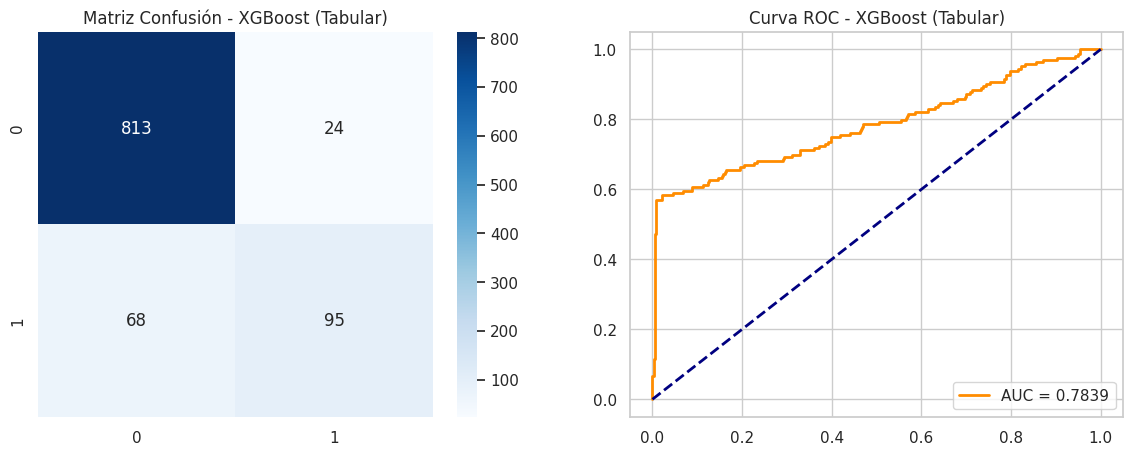

In [ ]:
print("\n🧠 ENTRENANDO XGBoost (Tabular)...")

xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=6,
    scale_pos_weight=float(np.sum(y_train==0)/np.sum(y_train==1)),
    eval_metric=["logloss", "error"]
)
model_tab = xgb_model.fit(X_tab_train, y_train, eval_set=[(X_tab_train, y_train), (X_tab_val, y_val)], verbose=True)
evaluate_and_plot_metrics(y_test, xgb_model.predict_proba(X_tab_test)[:, 1], "XGBoost (Tabular)")


🧠 ENTRENANDO RED NEURONAL (Sobre Embeddings de DistilBERT)...
Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9079 - loss: 0.2773 - val_accuracy: 0.9700 - val_loss: 0.1033
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9679 - loss: 0.1070 - val_accuracy: 0.9817 - val_loss: 0.0553
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9800 - loss: 0.0642 - val_accuracy: 0.9850 - val_loss: 0.0341
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0412 - val_accuracy: 0.9950 - val_loss: 0.0127
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9892 - loss: 0.0286 - val_accuracy: 1.0000 - val_loss: 0.0047


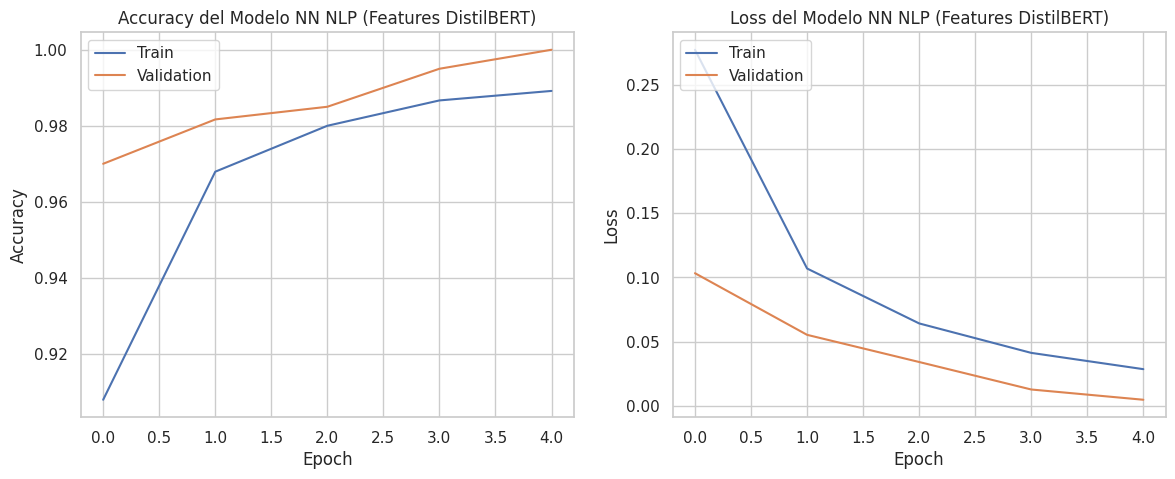


📈 EVALUACIÓN EN TEST SET: NN NLP (Features DistilBERT)
F1-Score: 0.9879 | AUC-ROC: 1.0000

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       837
      Fraude       0.98      1.00      0.99       163

    accuracy                           1.00      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       1.00      1.00      1.00      1000



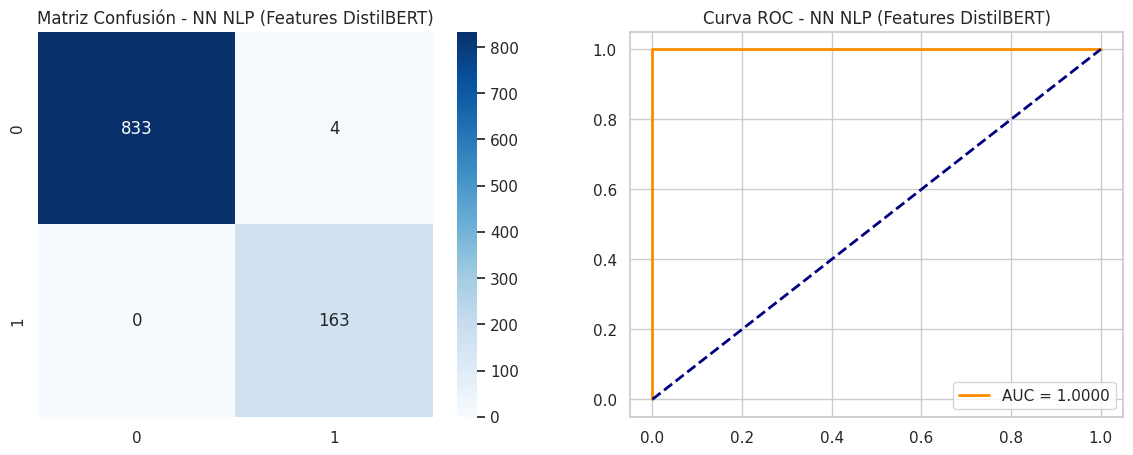

In [ ]:
print("\n🧠 ENTRENANDO RED NEURONAL (Sobre Embeddings de DistilBERT)...")

input_text = Input(shape=(768,), name="text_embedding_input")
x = Dense(128, activation='relu')(input_text)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.4)(x)
output_text = Dense(1, activation='sigmoid')(x)

nn_text_model = Model(inputs=input_text, outputs=output_text)
nn_text_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
class_weights_dict = dict(enumerate(class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

history_nn = nn_text_model.fit(
    X_text_train,
    y_train,
    validation_data=(X_text_val, y_val),
    epochs=5,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping],
    verbose=1
)

evaluate_and_plot_metrics(y_test, nn_text_model.predict(X_text_test, verbose=0).flatten(), "NN NLP (Features DistilBERT)", history=history_nn)


🧠 ENTRENANDO MODELO HÍBRIDO (META-LEARNER)...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1175 - loss: 0.7893 - val_accuracy: 0.2050 - val_loss: 0.7619
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2100 - loss: 0.7431 - val_accuracy: 0.3550 - val_loss: 0.7223
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4238 - loss: 0.7050 - val_accuracy: 0.5700 - val_loss: 0.6903
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6737 - loss: 0.6741 - val_accuracy: 0.7150 - val_loss: 0.6642
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8338 - loss: 0.6489 - val_accuracy: 0.8100 - val_loss: 0.6428
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9000 - loss: 0.6278 - val_accuracy: 0.8900 - val_loss: 0.6242
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9162 - loss: 0.6090 - val_accuracy: 0.9050 - val_loss: 0.6072
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9237 -

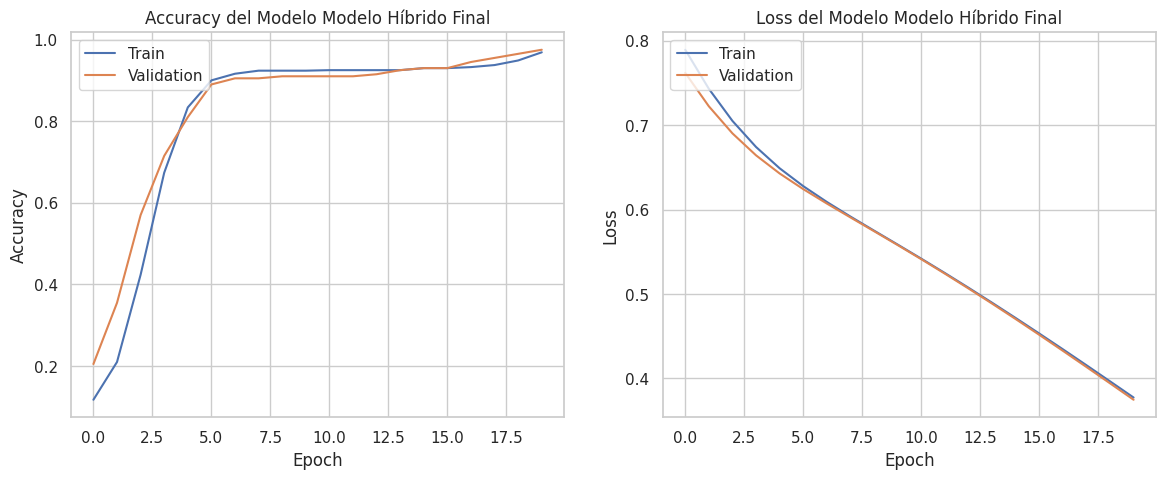


📈 EVALUACIÓN EN TEST SET: Modelo Híbrido Final
F1-Score: 0.9211 | AUC-ROC: 0.9996

              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99       837
      Fraude       0.99      0.86      0.92       163

    accuracy                           0.98      1000
   macro avg       0.98      0.93      0.95      1000
weighted avg       0.98      0.98      0.98      1000



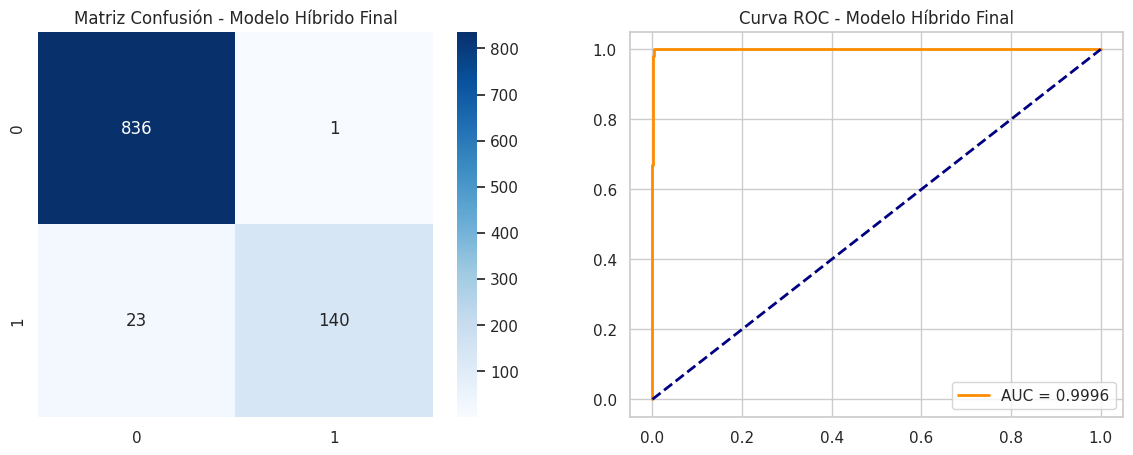

In [ ]:
print("\n🧠 ENTRENANDO MODELO HÍBRIDO (META-LEARNER)...")

pred_meta_xgb = xgb_model.predict_proba(X_tab_meta)[:, 1]
pred_meta_nn = nn_text_model.predict(X_text_meta, verbose=0).flatten()

meta_input = Input(shape=(2,), name="meta_input")
x = Dense(8, activation='relu')(meta_input)
meta_output = Dense(1, activation='sigmoid')(x)

meta_nn = Model(inputs=meta_input, outputs=meta_output)
meta_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_meta_nn = meta_nn.fit(
    np.column_stack((pred_meta_xgb, pred_meta_nn)),
    y_meta,
    validation_split=0.2,
    epochs=20,
    verbose=1
)

def predecir_fraude_stacking(X_tab_nuevo, texto_nuevo_str):
    p1 = xgb_model.predict_proba(X_tab_nuevo)[:, 1]
    emb_nuevo = extract_embeddings(texto_nuevo_str)
    p2 = nn_text_model.predict(emb_nuevo, verbose=0).flatten()
    meta_in = np.column_stack((p1, p2))
    return meta_nn.predict(meta_in, verbose=0).flatten(), p1[0], p2[0]

pred_test_stacking, _, _ = predecir_fraude_stacking(X_tab_test, df['Claim_Description'].iloc[idx_test].tolist())
evaluate_and_plot_metrics(y_test, pred_test_stacking, "Modelo Híbrido Final", history=history_meta_nn)


--- Comparación de Métricas de Modelos ---
XGBoost Model:
  F1-Score: 0.6738
  AUC-ROC: 0.7839

Hybrid Final Model (Stacking):
  F1-Score: 0.9211
  AUC-ROC: 0.9996

--- Conclusión ---
El Modelo Híbrido Final tiene un mejor F1-Score.
El Modelo Híbrido Final tiene un mejor AUC-ROC.


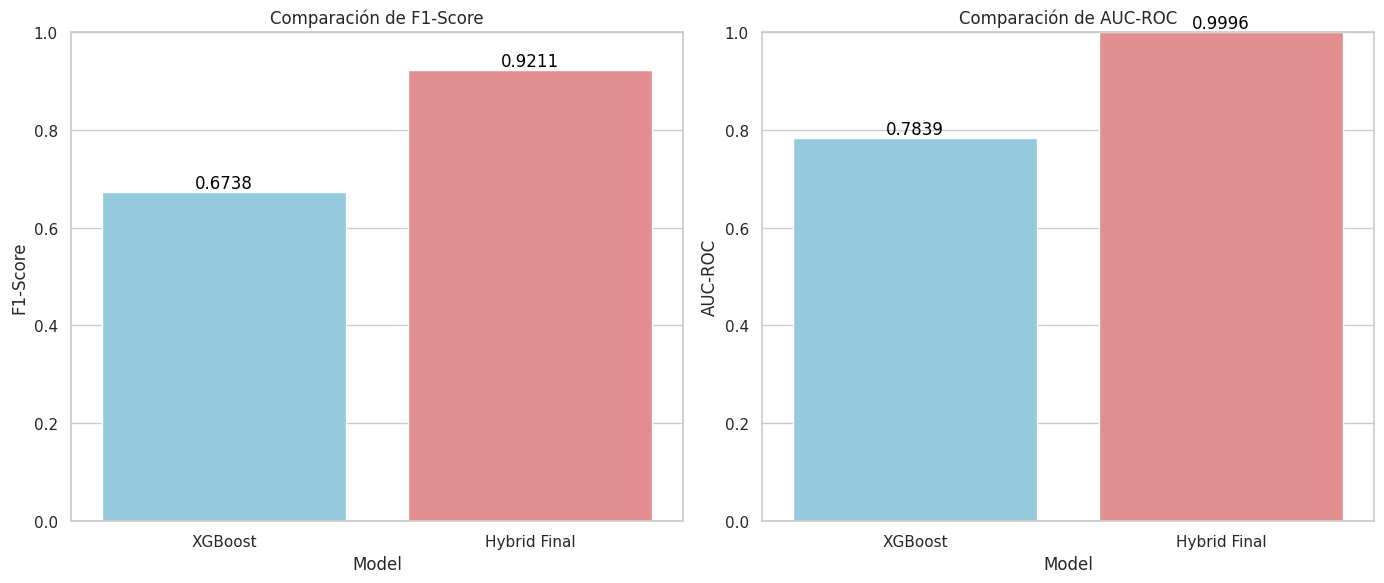

In [ ]:
prob_xgb_test = xgb_model.predict_proba(X_tab_test)[:, 1]
y_pred_xgb_bin = (prob_xgb_test > 0.5).astype(int)
f1_xgb = f1_score(y_test, y_pred_xgb_bin)
auc_xgb = roc_auc_score(y_test, prob_xgb_test)

prob_stack_test, _, _ = predecir_fraude_stacking(X_tab_test, df['Claim_Description'].iloc[idx_test].tolist())
y_pred_stack_bin = (prob_stack_test > 0.5).astype(int)
f1_stack = f1_score(y_test, y_pred_stack_bin)
auc_stack = roc_auc_score(y_test, prob_stack_test)

print("\n--- Comparación de Métricas ---")
print(f"XGBoost:       F1={f1_xgb:.4f}  AUC={auc_xgb:.4f}")
print(f"Híbrido Final: F1={f1_stack:.4f}  AUC={auc_stack:.4f}")

if f1_stack > f1_xgb:
    print("\nEl Modelo Híbrido Final tiene un mejor F1-Score.")
elif f1_xgb > f1_stack:
    print("\nEl Modelo XGBoost tiene un mejor F1-Score.")

if auc_stack > auc_xgb:
    print("El Modelo Híbrido Final tiene un mejor AUC-ROC.")
elif auc_xgb > auc_stack:
    print("El Modelo XGBoost tiene un mejor AUC-ROC.")

metrics_data = {
    'Model': ['XGBoost', 'Hybrid Final'],
    'F1-Score': [f1_xgb, f1_stack],
    'AUC-ROC': [auc_xgb, auc_stack]
}
metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x='Model', y='F1-Score', data=metrics_df, ax=axes[0], palette=['skyblue', 'lightcoral'], hue='Model', legend=False)
axes[0].set_title('Comparación de F1-Score')
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1)
for index, row in metrics_df.iterrows():
    axes[0].text(row.name, row['F1-Score'], round(row['F1-Score'], 4), color='black', ha="center", va='bottom')

sns.barplot(x='Model', y='AUC-ROC', data=metrics_df, ax=axes[1], palette=['skyblue', 'lightcoral'], hue='Model', legend=False)
axes[1].set_title('Comparación de AUC-ROC')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim(0, 1)
for index, row in metrics_df.iterrows():
    axes[1].text(row.name, row['AUC-ROC'], round(row['AUC-ROC'], 4), color='black', ha="center", va='bottom')

plt.tight_layout()
plt.savefig(VIZ_DIR / "comparacion_modelos.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
print("\n--- CARGANDO INTERFAZ DE PREDICCIÓN CON DISTILBERT ---")

engineered_cols = ['Report_Delay', 'Days_Since_Policy', 'Car_Age']
categorical_cols = list(label_encoders.keys())
numerical_cols = [col for col in X_tab_features if col not in categorical_cols and col not in engineered_cols]
numerical_cols.append('Model_Year')

input_widgets = {}
style = {'description_width': '150px'}
layout = widgets.Layout(width='400px', margin='0 0 5px 0')

for col in date_cols: input_widgets[col] = widgets.DatePicker(description=col.replace('_', ' '), value=datetime.date.today(), style=style, layout=layout)
for col in numerical_cols: input_widgets[col] = widgets.FloatText(description=col.replace('_', ' '), value=0.0, style=style, layout=layout)
for col in categorical_cols: input_widgets[col] = widgets.Dropdown(description=col.replace('_', ' '), options=list(label_encoders[col].classes_), style=style, layout=layout)
input_widgets['Claim_Description'] = widgets.Textarea(value='Colisión en intersección.', description='Descripción:', style=style, layout=widgets.Layout(width='820px', height='100px'))

tab_fechas = widgets.VBox([input_widgets[c] for c in date_cols])
tab_numeros = widgets.VBox([input_widgets[c] for c in numerical_cols])
cat_mid = len(categorical_cols) // 2
tab_categorias = widgets.HBox([widgets.VBox([input_widgets[c] for c in categorical_cols[:cat_mid]]), widgets.VBox([input_widgets[c] for c in categorical_cols[cat_mid:]])])
tabs = widgets.Tab(children=[tab_fechas, tab_numeros, tab_categorias])
tabs.set_title(0, 'Fechas'); tabs.set_title(1, 'Números'); tabs.set_title(2, 'Categorías')

predict_button = widgets.Button(description='🔍 Evaluar Siniestro', button_style='danger', layout=widgets.Layout(width='300px', height='50px', margin='20px 0 0 0'))
output_area = widgets.Output()

display(HTML("<h3>Sistema Detección Fraude (Stacking: XGBoost + DistilBERT/PyTorch)</h3>"))
display(tabs, input_widgets['Claim_Description'], predict_button, output_area)

def on_predict_button_clicked(b):
    with output_area:
        clear_output(wait=True)
        print("Analizando variables tabulares e infiriendo contexto lingüístico con DistilBERT...")

        raw_data = {key: widget.value for key, widget in input_widgets.items() if key != 'Claim_Description'}
        input_df = pd.DataFrame([raw_data])

        for col in date_cols: input_df[col] = pd.to_datetime(input_df[col])
        input_df['Report_Delay'] = (input_df['Date_Reported'] - input_df['Incident_Date']).dt.days.fillna(0)
        input_df['Days_Since_Policy'] = (input_df['Incident_Date'] - input_df['Policy_Start_Date']).dt.days.fillna(0)
        input_df['Car_Age'] = input_df['Incident_Date'].dt.year - input_df['Model_Year'] if 'Model_Year' in input_df.columns else 0

        for col, le in label_encoders.items():
            if col in input_df.columns: input_df[col] = le.transform(input_df[col].astype(str))

        X_tab_new = input_df[X_tab_features].values
        texto_crudo = [input_widgets['Claim_Description'].value]

        prob_stack, prob_xgb, prob_nn = predecir_fraude_stacking(X_tab_new, texto_crudo)

        display(HTML("<hr>"))
        color, icon = ('red', '⚠️ ALERTA') if prob_stack > 0.5 else ('green', '✅ APROBADO')
        display(HTML(f"<h2 style='color:{color};'>{icon}: Probabilidad Global de Fraude: {prob_stack[0]*100:.2f}%</h2>"))
        print(f" -> Modelo Tabular (XGBoost) indica: {prob_xgb*100:.2f}%")
        print(f" -> Modelo NLP (DistilBERT) indica: {prob_nn*100:.2f}%")

predict_button.on_click(on_predict_button_clicked)


--- CARGANDO INTERFAZ DE PREDICCIÓN CON DISTILBERT ---


Textarea(value='Colisión en intersección.', description='Descripción:', layout=Layout(height='100px', width='8…

Button(button_style='danger', description='🔍 Evaluar Siniestro', layout=Layout(height='50px', margin='20px 0 0…

Output()

In [ ]:
import joblib

print("\n[*] Guardando artefactos del modelo en ARTIFACTS_DIR...")

# Modelo tabular - XGBoost
xgb_model.save_model(str(ARTIFACTS_DIR / "xgb_model.json"))
print(f"  ✅ XGBoost guardado en {ARTIFACTS_DIR / 'xgb_model.json'}")

# Modelo NLP - Red Neuronal sobre embeddings DistilBERT
nn_text_model.save(str(ARTIFACTS_DIR / "nn_text_model.keras"))
print(f"  ✅ NN NLP guardado en {ARTIFACTS_DIR / 'nn_text_model.keras'}")

# Meta-Learner (Stacking)
meta_nn.save(str(ARTIFACTS_DIR / "meta_nn.keras"))
print(f"  ✅ Meta-Learner guardado en {ARTIFACTS_DIR / 'meta_nn.keras'}")

# Preprocesamiento: LabelEncoders y nombres de features
joblib.dump(label_encoders, ARTIFACTS_DIR / "label_encoders.pkl")
print(f"  ✅ LabelEncoders guardados en {ARTIFACTS_DIR / 'label_encoders.pkl'}")

joblib.dump(X_tab_features, ARTIFACTS_DIR / "feature_names.pkl")
print(f"  ✅ Feature names guardados en {ARTIFACTS_DIR / 'feature_names.pkl'}")

print(f"\n[✔] Todos los artefactos guardados en {ARTIFACTS_DIR}")
